# CNN Introduction
This notebook gives a high-level overview of convolutional neural networks (CNNs) and small, hands-on NumPy demos to build intuition about convolution, stride, padding, and pooling.

## Outline
- What is convolution (intuition)
- Discrete convolution / cross-correlation math
- Kernels, stride, padding, pooling
- Small NumPy demos: conv2d, padding, stride, pooling
- Practical tips and next steps

## What is convolution?
Convolution is a local, linear operation that mixes nearby values using a small kernel (filter). In computer vision we slide a small kernel across an image to detect features (edges, textures, patterns).
In many deep learning libraries the operation used in CNN layers is actually *cross-correlation* (not the strict mathematical convolution). For a 2D input $I$ and kernel $K$, the cross-correlation at location $(i,j)$ is:
$$ (Itar K)[i,j] = um_{m}um_{n} I[i+m, j+n]K[m,n] $$
While the mathematical convolution flips the kernel, CNN implementations typically omit the flip — the intuition and feature extraction behavior are the same for learning.

## Key parameters
- Kernel (filter): small matrix, e.g. 3x3, 5x5.
- Stride: how many pixels we move the kernel each step.
- Padding: adding border pixels (usually zeros) so output size can be controlled.
- Pooling: downsampling (max-pooling, average-pooling) to reduce spatial size and add invariance.

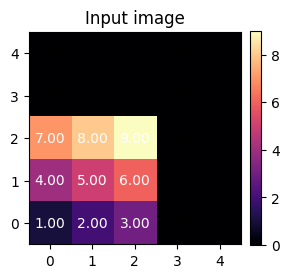

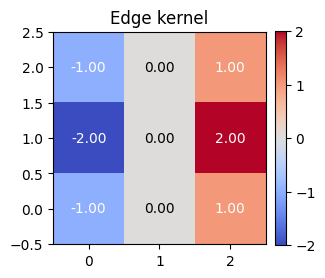

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

# Small helper to display a matrix as an image with annotations
def show_matrix(mat, title=None, cmap='viridis'):
    plt.figure(figsize=(3,3))
    plt.imshow(mat, cmap=cmap, interpolation='nearest')
    plt.colorbar(fraction=0.046, pad=0.04)
    if title:
        plt.title(title)
    for (i, j), val in np.ndenumerate(mat):
        plt.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if abs(val)>0.5 else 'black')
    plt.gca().invert_yaxis()
    plt.show()

# Example image and a simple edge detector kernel
image = np.array([[1, 2, 3, 0, 0],
                  [4, 5, 6, 0, 0],
                  [7, 8, 9, 0, 0],
                  [0, 0, 0, 0, 0],
                  [0, 0, 0, 0, 0]], dtype=float)
kernel = np.array([[ -1, 0, 1],
                   [ -2, 0, 2],
                   [ -1, 0, 1]], dtype=float)  # Sobel-like

show_matrix(image, 'Input image', cmap='magma')
show_matrix(kernel, 'Edge kernel', cmap='coolwarm')

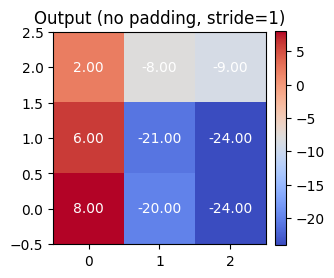

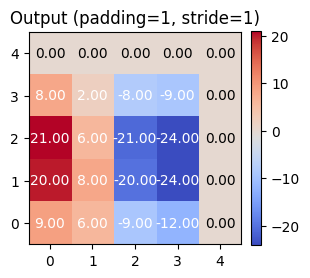

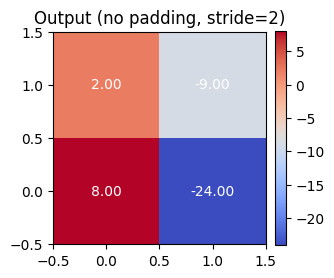

In [2]:
def pad_image(img, pad):
    if pad == 0:
        return img
    return np.pad(img, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)

def conv2d_naive(img, kernel, stride=1, padding=0):
    # cross-correlation style (no kernel flip)
    img_p = pad_image(img, padding)
    k_h, k_w = kernel.shape
    i_h, i_w = img_p.shape
    out_h = (i_h - k_h) // stride + 1
    out_w = (i_w - k_w) // stride + 1
    out = np.zeros((out_h, out_w), dtype=float)
    for y in range(out_h):
        for x in range(out_w):
            patch = img_p[y*stride:y*stride+k_h, x*stride:x*stride+k_w]
            out[y, x] = np.sum(patch * kernel)
    return out

# Demos: no padding vs padding, stride 1 vs 2
out_no_pad = conv2d_naive(image, kernel, stride=1, padding=0)
out_pad = conv2d_naive(image, kernel, stride=1, padding=1)
out_stride2 = conv2d_naive(image, kernel, stride=2, padding=0)

show_matrix(out_no_pad, 'Output (no padding, stride=1)', cmap='coolwarm')
show_matrix(out_pad, 'Output (padding=1, stride=1)', cmap='coolwarm')
show_matrix(out_stride2, 'Output (no padding, stride=2)', cmap='coolwarm')

## Visualizing stride and padding effects
- Padding preserves spatial size (when chosen appropriately).
- Larger stride reduces spatial resolution of the feature map.
Try changing kernel values, stride, and padding to see different behaviours.

## Pooling (downsampling)
Pooling layers reduce spatial dimensions and provide some translational invariance. The most common are max-pooling and average-pooling.

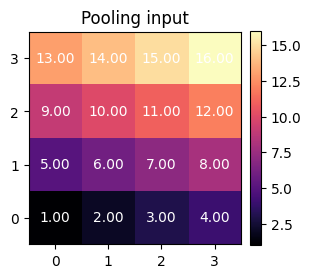

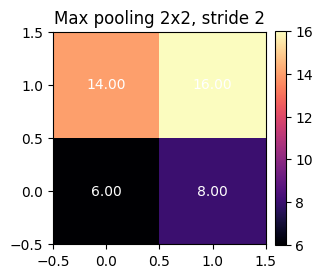

In [3]:
def max_pool2d(img, pool_size=2, stride=2):
    h, w = img.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    out = np.zeros((out_h, out_w), dtype=img.dtype)
    for y in range(out_h):
        for x in range(out_w):
            patch = img[y*stride:y*stride+pool_size, x*stride:x*stride+pool_size]
            out[y, x] = np.max(patch)
    return out

pool_demo = np.array([[1,2,3,4], [5,6,7,8], [9,10,11,12], [13,14,15,16]], dtype=float)
show_matrix(pool_demo, 'Pooling input', cmap='magma')
show_matrix(max_pool2d(pool_demo, pool_size=2, stride=2), 'Max pooling 2x2, stride 2', cmap='magma')

## Practical notes
- CNN layers usually: Conv -> Activation (ReLU) -> (BatchNorm) -> Pooling (optional).
- Use small kernels (3x3) stacked to get larger receptive fields with fewer parameters.
- BatchNorm and proper initialization make training stable; use dropout and augmentation to regularize.
- In modern pipelines prefer frameworks (PyTorch, TensorFlow) for performance and GPU acceleration — this notebook focuses on intuition.

## Next steps
- Implement a tiny CNN in NumPy (forward + backward) — solidifies gradients intuition.
- Re-implement using PyTorch / TensorFlow and train on a small dataset (CIFAR-10 / MNIST).
- Explore transfer learning and modern architectures (ResNet, EfficientNet).

**References**: Stanford CS231n notes, PyTorch tutorials, and good blog posts on CNNs.